# Hotel Reservation System using KNN Classifier
### Major Project – Machine Learning with Python

## Introduction
In this project, I tried to build a machine learning model to predict whether a hotel booking will be canceled or not.

I mainly used the K-Nearest Neighbors (KNN) algorithm as required. Along with that, I also tested Logistic Regression to see if any improvement in performance can be achieved.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [36]:
df = pd.read_csv('Hotel Reservations.csv')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## Data Visualization
Understanding distribution of booking status.

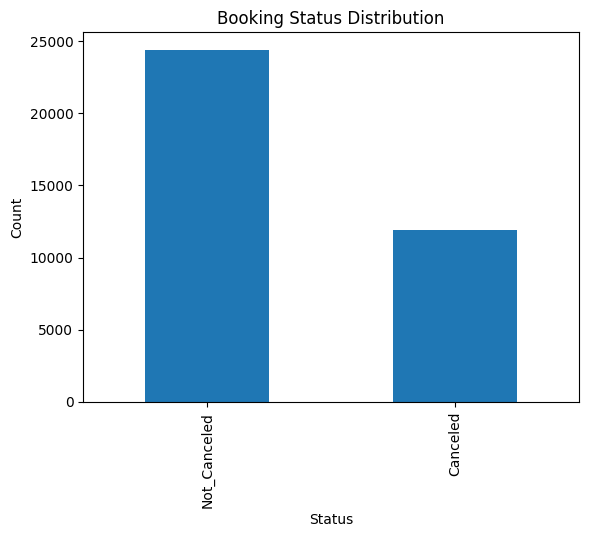

In [37]:
df['booking_status'].value_counts().plot(kind='bar')
plt.title("Booking Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

## Dataset Overview
The dataset contains details about hotel bookings such as number of people, type of room, meal plan, and booking status.

These features help in understanding the behavior of customers and whether they are likely to cancel the booking.

In [38]:
# Drop unnecessary column
if 'Booking_ID' in df.columns:
    df.drop('Booking_ID', axis=1, inplace=True)

# Feature engineering
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']

## Feature Analysis
Analyzing how lead time affects booking cancellation.

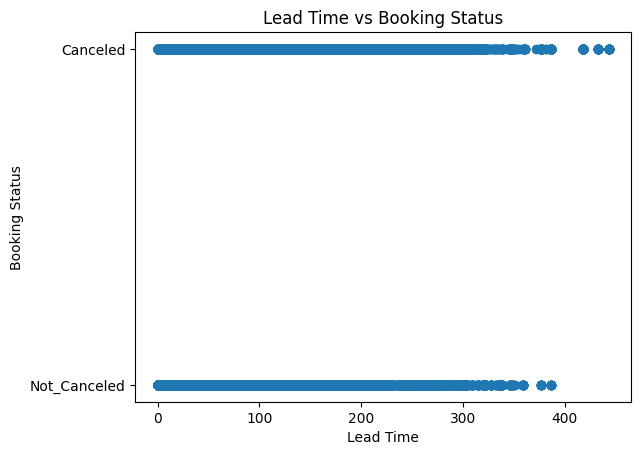

In [39]:
plt.scatter(df['lead_time'], df['booking_status'])
plt.title("Lead Time vs Booking Status")
plt.xlabel("Lead Time")
plt.ylabel("Booking Status")
plt.show()

In [40]:
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [41]:
X = df.drop('booking_status', axis=1)
y = df['booking_status']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling
Since KNN is based on distance, scaling is necessary to make sure that all features contribute equally.

In [43]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
best_k = 1
best_acc = 0

for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("Best K:", best_k)
print("Best Accuracy (KNN):", best_acc)

Best K: 1
Best Accuracy (KNN): 0.8534803583735355


In [27]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [28]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8534803583735355
Confusion Matrix:
 [[1893  523]
 [ 540 4299]]

Classification Report:
               precision    recall  f1-score   support

    Canceled       0.78      0.78      0.78      2416
Not_Canceled       0.89      0.89      0.89      4839

    accuracy                           0.85      7255
   macro avg       0.83      0.84      0.84      7255
weighted avg       0.85      0.85      0.85      7255



In [29]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [30]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8066161268090972


## Model Comparison
After training both models, I observed that Logistic Regression gives slightly better accuracy compared to KNN.

However, KNN still performs well and satisfies the main requirement of the project.

## Model Comparison

In [31]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

KNN Accuracy: 0.8534803583735355
Logistic Regression Accuracy: 0.8066161268090972


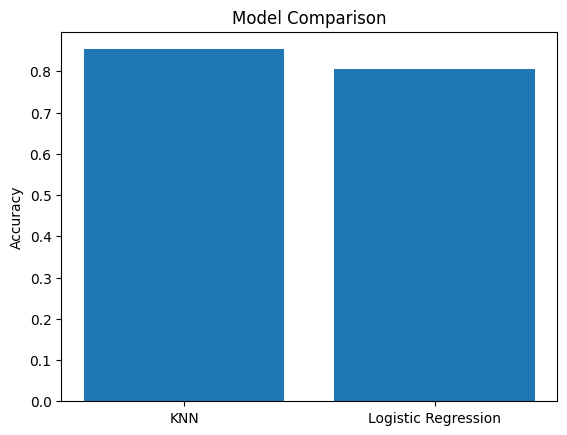

In [32]:
models = ['KNN', 'Logistic Regression']
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_lr)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

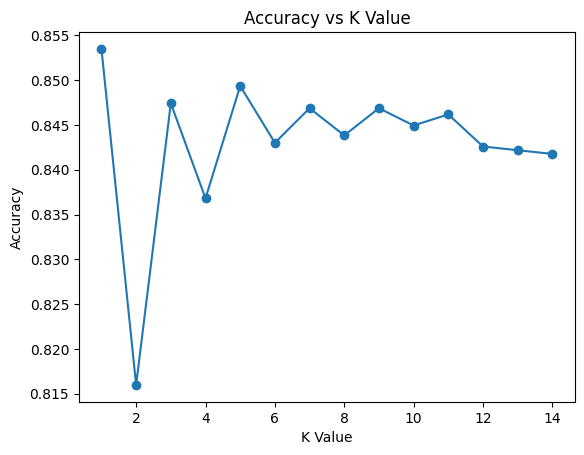

In [33]:
k_values = []
accuracies = []

for k in range(1, 15):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))

    k_values.append(k)
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")
plt.show()

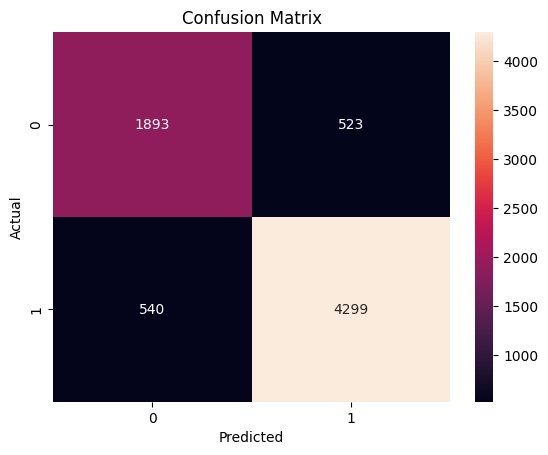

In [34]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Conclusion
In this project, I implemented KNN to predict hotel booking cancellations and also compared it with Logistic Regression.

From the results, both models performed well, but Logistic Regression showed slightly better accuracy. This shows that machine learning can be useful in predicting customer behavior.

## Source
Dataset: Hotel Reservations Dataset  
Reference: Kaggle